# Example of usage of waveguide code

First we import a geometry (either gmsh or ngsolve based) along with the labels of its boundary regions

In [1]:
R = 2.
H = 1.

NGSOLVE = True

lc = 0.3

# if NGSOLVE:
#     from cases.waveguide.ngsolve_geometries import Empty, WaveguideRegions
#     mesh = Empty(R=R, H=H, verbosity=0, lc=lc)
# else:
#     from cases.waveguide.gmsh_geometries import Empty, WaveguideRegions
#     mesh = Empty(R=R, H=H, verbose=True, lc=lc)


In [2]:
from cases.waveguide.base import CleanWaveguide

waveguide = CleanWaveguide(R=R, H=H, lc=lc)

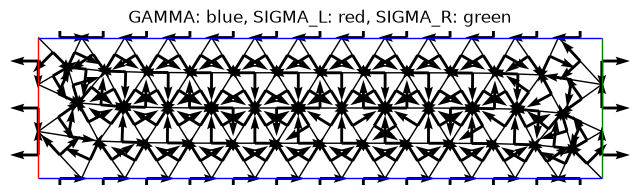

In [3]:
waveguide.plot()

In [4]:
list(waveguide.mesh.boundary_regions)

[<BoundaryRegions.GAMMA: 'Gamma'>,
 <BoundaryRegions.SIGMA_L: 'Sigma_L'>,
 <BoundaryRegions.SIGMA_R: 'Sigma_R'>]

To that regions we can apply different boundary conditions. In our case we will set a radianting boundary condition both in $\Sigma_L$ and $\Sigma_R$, and a _soundhard_ boundary condition at $\Gamma$.

The boundary conditions are just a dictionary:

In [5]:
from trefftz.dg.boundary_conditions import SoundHardBC, NtDBC

In [6]:
boundary_conditions = {waveguide.mesh.boundary_regions.GAMMA: SoundHardBC(),
                       waveguide.mesh.boundary_regions.SIGMA_L: NtDBC(truncating_radius=R, data=1.), #I need to refine this, right now "data" is nonsense
                       waveguide.mesh.boundary_regions.SIGMA_R: NtDBC(truncating_radius=R, data=1.)}

Each boundary condition corresponds to a given kernel (this perhaps should be a default). There are general kernels for _soundhard_ or _transmission_ kernels:

In [7]:
from trefftz.dg.serial_fluxes import UltraWeakFlux, NeumannFlux


as well as specific ones (for the waveguide):

In [8]:
from cases.waveguide.kernels import NtD_nonlocal, NtDLocal

ImportError: cannot import name 'NtD_nonlocal' from 'cases.waveguide.kernels' (/home/manuel/Documentos/Trefftz/cases/waveguide/kernels.py)

Now the numerics (the configuration of kernels) is almost a dictionary:

In [21]:
from trefftz.dg.assemblers import SerialNumerics
n = 1
numerics = SerialNumerics(interior_kernel=UltraWeakFlux(a=0.5, b=0.5),
                          local_boundary_kernels={SoundHardBC: NeumannFlux(d_1=0.5),
                                                  NtDBC: NtDLocal(R=R, d_2=0.5, n=n, H=H)},
                          nonlocal_boundary_kernels={NtDBC: NtD_nonlocal(R=R, d_2=0.5, M=10, H=H)})

We should also choose a local basis

In [45]:
from trefftz.dg.basis import LinearlySpacedBasis
k = 8.0
basis = LinearlySpacedBasis(N_elements=waveguide.mesh.n_triangles, k=k, N_theta=11)
basis.N_DOF

1122

and an assembler:

In [34]:
from trefftz.dg.assemblers import SerialAssembler

assembler = SerialAssembler(mesh=waveguide.mesh, boundary_conditions=boundary_conditions, numerics=numerics, basis=basis)

so we can set the problem:

In [35]:
from trefftz.problem import Problem  # (I don't think "problem" uses "numerics" any more.)
P = Problem(mesh=waveguide.mesh, wavenumber=k, basis=basis, boundary_conditions=boundary_conditions, assembler=assembler, direct_solver=False)  #, numerics=numerics)

In [36]:
A = P.assemble_LHS()

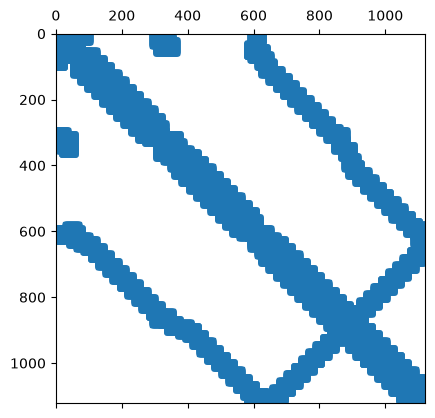

In [37]:
import matplotlib.pyplot as plt 
plt.spy(A)

In [38]:
b = P.assemble_RHS()

In [39]:
P.solve()

In [40]:
P.u_h.coefficients.reshape((-1,3))

array([[-0.02836296+0.21381817j,  0.02637995-0.32571585j,
        -0.03357171-0.15438455j],
       [ 0.18688047-0.4144107j ,  0.27069517+0.36185264j,
        -0.21292581-0.17426887j],
       [-0.12676659-0.39133675j,  0.03231157+0.45088264j,
         0.22839679-0.00549643j],
       ...,
       [-0.15504059-0.00398754j,  0.07934304-0.11900335j,
         0.19098491-0.11723252j],
       [ 0.00028153-0.10185751j, -0.17614088+0.08965925j,
        -0.16493404+0.01832288j],
       [ 0.02626721-0.11834635j, -0.09576123+0.02425984j,
         0.27695635-0.12596102j]], shape=(374, 3))

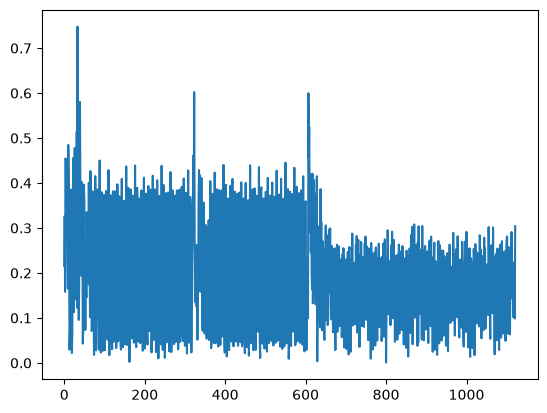

In [41]:
import numpy as np
plt.plot(np.abs(P.u_h.coefficients))

In [42]:
import numpy as np
N = 200
x = np.linspace(-R, R, N)
y = np.linspace(0., H, int(N*H/R))
X, Y = np.meshgrid(x, y)
Z = P.u_h(X.ravel(), Y.ravel()).reshape(X.shape)

(0.0, 1.0)

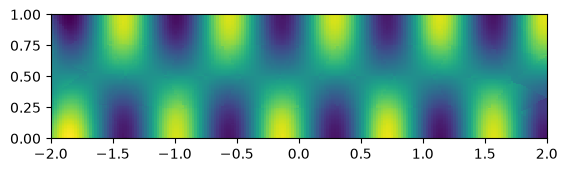

In [44]:
import matplotlib.pyplot as plt 
plt.pcolormesh(X, Y, Z.real)
plt.axis('square')
plt.xlim([-R, R])
plt.ylim([0., H])